<a href="https://colab.research.google.com/github/hoangtran31251024560-star/tranvanhoang.github.io/blob/main/nhandienkhuonmat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt


train_dir = '/content/drive/MyDrive/Ảnh Lớp IC'

img_width, img_height = 280, 280
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1/255,
    shear_range=0.2,
    zoom_range=0.2,
    height_shift_range=0.2,
    width_shift_range=0.2, # Sửa tên biến từ img_width_shift_range thành width_shift_range
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1562 images belonging to 34 classes.


In [20]:
from keras.layers import Input, Conv2D, MaxPool2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(34, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(34, activation='softmax')
])


In [22]:

num_classes = train_generator.num_classes
print(f"Số lượng lớp thực tế: {num_classes}")


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
epochs = 5
history = model.fit(train_generator, epochs=epochs)

Số lượng lớp thực tế: 34


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 278, 278, 34)   │           952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 139, 139, 34)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 137, 137, 64)   │        19,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 68, 68, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 66, 66, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    17,842,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,941,146 (68.44 MB)

 Trainable params: 17,941,146 (68.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 703ms/step - accuracy: 0.7106 - loss: 0.9347
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 734ms/step - accuracy: 0.7618 - loss: 0.7767
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 708ms/step - accuracy: 0.7759 - loss: 0.7505
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 74s 750ms/step - accuracy: 0.7849 - loss: 0.6701
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 674ms/step - accuracy: 0.7958 - loss: 0.6106


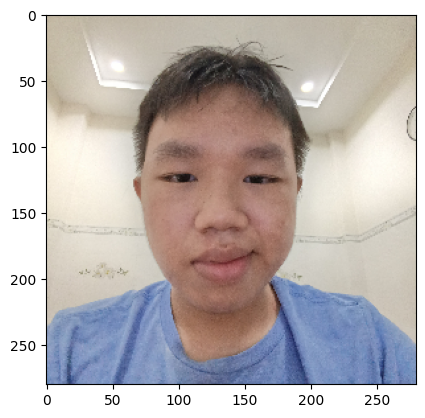

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
Du doan la: Nguyễn Huy Hoàng


In [24]:
from keras.utils import load_img
import matplotlib.pyplot as plt

import numpy as np
path='/content/IMG_20260526_201834_1.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/255
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
print('Du doan la:',class_labels[prediction])

In [ ]:
model.save('nhandienkhuonmat.h5')
from keras.models import load_model
model=load_model('nhandienkhuonmat.h5')